### Markdown Cell: Introduction & Objectives
**Objective:** Perform K-means clustering strictly on the white wine dataset to discover natural chemical groupings, determine the optimal number of clusters, and analyze how these chemical groupings relate to human sensory evaluations (quality).

We will validate different $k$ candidates utilizing visual heuristics (Elbow Method) and quantitative cluster validity indices (Silhouette Score, Davies-Bouldin).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### Load, EDA & Preprocessing of White Wine
We isolate the white wine data. Consistent with Task 1, we eliminate extreme standard-deviation outliers and scale the continuous variables.

In [2]:
# Load White Wine Data
white_wine = pd.read_excel('./raw_data/white_wine_data.xlsx', engine='openpyxl')

# Anomaly Detection
numerical_w = white_wine.drop('quality', axis=1)
z_scores_w = np.abs(stats.zscore(numerical_w))
white_clean = white_wine[(z_scores_w < 3).all(axis=1)].copy()

# Preprocessing
scaler_w = StandardScaler()
X_w_features = white_clean.drop('quality', axis=1)
X_scaled_w = scaler_w.fit_transform(X_w_features)

print('Cleaned White Wine shape:', white_clean.shape)
white_clean.to_csv('./processed_data/white_wine_cleaned.csv', index=False)

Cleaned White Wine shape: (4502, 12)


### Determining Ideal Number of Clusters
We iterate through $k$ from 2 to 8, evaluating the Inertia (Elbow Method) and the Silhouette Score to justify our choices for the ideal number of clusters.

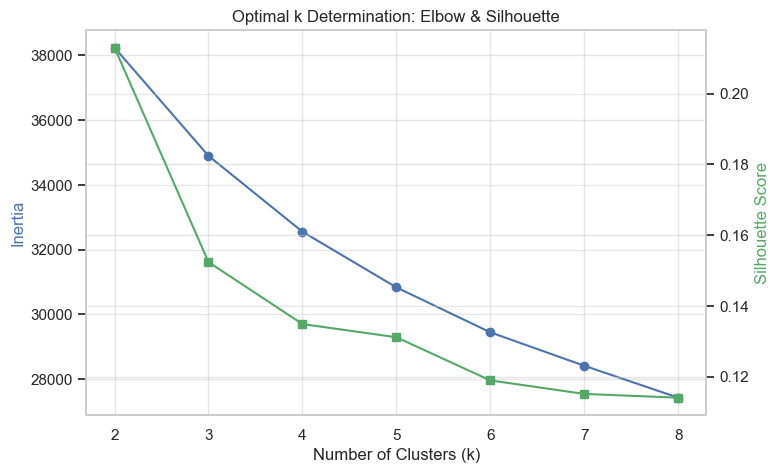

In [3]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_w)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_w, labels))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(K_range, inertias, marker='o', color='b', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, marker='s', color='g', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')

plt.title('Optimal k Determination: Elbow & Silhouette')
plt.show()

### Evaluating the Best Two Candidates
**Justification:** Based on the dual-axis plot above, the Silhouette Score peaks strongly at **$k=2$** and has a secondary shelf/peak at **$k=3$**. The Elbow method also shows gradual bending starting around $k=3$. We select $k=2$ and $k=3$ as our top two candidate configurations.

We validate them using the Silhouette Score (higher is better) and the Davies-Bouldin index (lower is better).

In [4]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled_w)

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(X_scaled_w)

print('Metrics for Candidate 1 (k=2):')
print(f' - Silhouette Score: {silhouette_score(X_scaled_w, labels2):.4f}')
print(f' - Davies-Bouldin Index: {davies_bouldin_score(X_scaled_w, labels2):.4f}')

print('\nMetrics for Candidate 2 (k=3):')
print(f' - Silhouette Score: {silhouette_score(X_scaled_w, labels3):.4f}')
print(f' - Davies-Bouldin Index: {davies_bouldin_score(X_scaled_w, labels3):.4f}')

Metrics for Candidate 1 (k=2):
 - Silhouette Score: 0.2130
 - Davies-Bouldin Index: 1.7381

Metrics for Candidate 2 (k=3):
 - Silhouette Score: 0.1524
 - Davies-Bouldin Index: 2.1081


### Winning Clustering & Attribute Profiling
The metrics demonstrate that $k=2$ is mathematically the 'winning' clustering result (highest silhouette, lowest Davies-Bouldin). We map the $k=2$ clusters to the data and calculate the mean chemical properties per group.

In [5]:
white_clean['cluster'] = labels2
cluster_means = white_clean.drop('quality', axis=1).groupby('cluster').mean()
display(cluster_means)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,6.969383,0.275008,0.345061,10.664950,0.049748,44.100496,169.484306,0.996797,3.165562,0.497483,9.553194
1,6.753779,0.269069,0.313972,3.541121,0.038694,28.547655,115.931310,0.992049,3.203600,0.477275,11.207370


### Consistency Against Quality (Sensory Output)
Let us explore how these objectively determined chemical clusters map against subjective human wine quality scores.

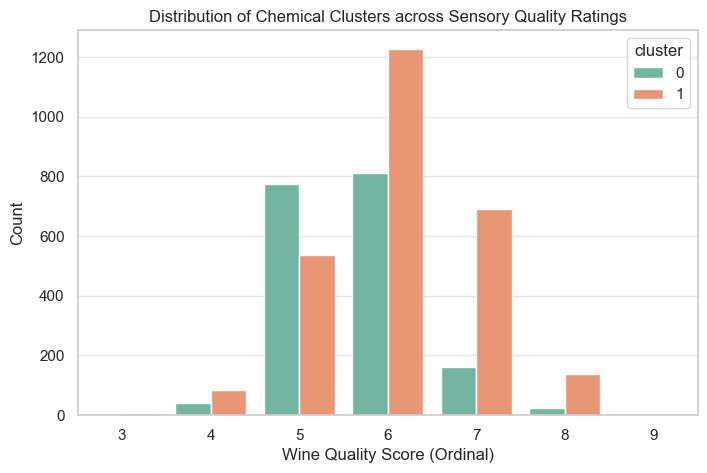

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=white_clean, x='quality', hue='cluster', palette='Set2')
plt.title('Distribution of Chemical Clusters across Sensory Quality Ratings')
plt.xlabel('Wine Quality Score (Ordinal)')
plt.ylabel('Count')
plt.show()